In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
from modules import comoving_density

from matplotlib.ticker import AutoMinorLocator

In [2]:
params = {'legend.fontsize':'x-large',
          'axes.labelsize':'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large',
          'figure.facecolor':'w',
          'xtick.top':True,
          'ytick.right':True,
          'xtick.direction':'in',
          'ytick.direction':'in',
         } 
plt.rcParams.update(params)

In [24]:
spec = Table(fitsio.read('/Volumes/WD Elements/dr9/truth/south/matched/COSMOS2015_Laigle+_v1.1-match.fits'))
cat = Table(fitsio.read('/Volumes/WD Elements/dr9/truth/south/matched/ls-dr9.0-COSMOS2015_Laigle+_v1.1-match.fits'))
print(len(spec), len(cat))

197495 197495


In [25]:
mask = (cat['NOBS_G']>=1) & (cat['NOBS_R']>=1) & (cat['NOBS_Z']>=1)
cat = cat[mask]
spec = spec[mask]
print(len(spec), len(cat))

197427 197427


In [26]:
mask = spec['ZPDF']>=0
cat = cat[mask]
spec = spec[mask]
print(len(spec), len(cat))

186098 186098


In [27]:
mask_quality = np.full(len(cat), True)
mask_quality &= (cat['FLUX_R'] > 0)   # ADM quality in r.
mask_quality &= (cat['FLUX_Z'] > 0) & (cat['FIBERFLUX_Z'] > 0)   # ADM quality in z.
mask_quality &= (cat['FLUX_W1'] > 0)  # ADM quality in W1.
mask_quality &= (cat['GAIA_PHOT_G_MEAN_MAG'] == 0) | (cat['GAIA_PHOT_G_MEAN_MAG'] > 18)  # remove bright GAIA sources
cat = cat[mask_quality]
spec = spec[mask_quality]
print(len(spec), len(cat))

143262 143262


In [28]:
area = 2.595
print(area)

2.595


In [29]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_G']*10**(0.4*3.214*cat['EBV']), 1e-7, None))
    cat['rmag'] = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_R']*10**(0.4*2.165*cat['EBV']), 1e-7, None))
    cat['zmag'] = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_Z']*10**(0.4*1.211*cat['EBV']), 1e-7, None))
    cat['w1mag'] = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_W1']*10**(0.4*0.184*cat['EBV']), 1e-7, None))
    cat['w2mag'] = 22.5 - 2.5*np.log10(np.clip(cat['FLUX_W2']*10**(0.4*0.113*cat['EBV']), 1e-7, None))
    cat['gfibermag'] = 22.5 - 2.5*np.log10(np.clip(cat['FIBERFLUX_G']*10**(0.4*3.214*cat['EBV']), 1e-7, None))
    cat['rfibermag'] = 22.5 - 2.5*np.log10(np.clip(cat['FIBERFLUX_R']*10**(0.4*2.165*cat['EBV']), 1e-7, None))
    cat['zfibermag'] = 22.5 - 2.5*np.log10(np.clip(cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV']), 1e-7, None))

In [30]:
# Apply the LRG non-stellar cut
mask_basic = zmag - w1mag > 0.8 * (rmag - zmag) - 1.1  # LRG non-stellar cut
mask_basic &= rmag - zmag > 0.1
mask_basic &= zfibermag<21.6

print(np.sum(mask_basic), np.sum(mask_basic)/len(cat))

15366 0.10725803074088035


In [31]:
principal = cat['zfibermag']<21.6
principal &= (cat['TYPE']!='PSF') | (cat['zmag'] - cat['w1mag'] > 0.8 * (cat['rmag'] - cat['zmag']) - 1.1)  # stellar rejection
print(np.sum(principal), np.sum(principal)/len(cat))

filler = (cat['zfibermag']>=21.6) & (cat['zfibermag']<22.4)
print(np.sum(filler), np.sum(filler)/len(cat))
mask_highz = ((cat['gmag']-cat['rmag']) < 1.2 * (cat['rmag']-cat['zmag'])) | (cat['rmag']-cat['zmag']>1.3)  # high-z cuts
filler_hip = filler & mask_highz
filler_lop = filler & (~mask_highz)
print(np.sum(filler), np.sum(filler_hip)/len(cat))
print(np.sum(filler), np.sum(filler_lop)/len(cat))

cat['principal'] = principal.copy()
cat['filler_hip'] = filler_hip.copy()
cat['filler_lop'] = filler_lop.copy()

# mask = (cat['zmag']-cat['w1mag']) > 1.*(cat['rmag']-cat['zmag']) - 1.2
# print(np.sum(cat['filler_hip'] & mask)/np.sum(cat['filler_hip']))
# cat['filler_hip'] &= mask

mask = cat['principal'] | cat['filler_hip'] | cat['filler_lop']
cat = cat[mask]
spec = spec[mask]
print(len(cat))

15941 0.11127165612653739
22316 0.15577054627186554
22316 0.08561935474864235
22316 0.07015119152322319
38257


In [46]:
from astropy.cosmology import FlatLambdaCDM

H0=100
Om0=0.3
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)

In [63]:
binsize_txt = 0.1
bins_txt = np.arange(0, 1.42, binsize_txt)

# surface density
mask = cat['principal'].copy()
surf_density_bright = np.histogram(spec['ZPDF'][mask], weights=np.ones(np.sum(mask))/(np.sum(mask)/6600.), bins=bins_txt)[0]
mask = cat['principal'] | cat['filler_lop'] | cat['filler_hip']
surf_density_bright_and_faint = np.histogram(spec['ZPDF'][mask], weights=np.ones(np.sum(mask))/(np.sum(mask)/14500.), bins=bins_txt)[0]

t = Table()
t['zmin'] = bins_txt[:-1]
t['zmax'] = bins_txt[1:]
t['zmin'].format = '%.2f'
t['zmax'].format = '%.2f'
t['surface_density'] = surf_density_bright
t['surface_density'].format = '%.2f'
t['comoving_density'] = 0.
for index in range(len(t)):
    shell_volume = cosmo.comoving_volume(t['zmax'][index]).to_value('Mpc^3')-cosmo.comoving_volume(t['zmin'][index]).to_value('Mpc^3')
    t['comoving_density'][index] = t['surface_density'][index] * (4*np.pi*(180/np.pi)**2) / shell_volume
t['comoving_density'].format = '%.7f'
t.write('data/desi2_low_z_dndz_zfiber_less_than_21.6.txt', format='ascii.commented_header', 
       formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'surface_density':'%.7g'},
       overwrite=True)
print('surface density in (deg^-2)')
print('comoving density in (h^3 Mpc^-3)')
print(t)
print()

t = Table()
t['zmin'] = bins_txt[:-1]
t['zmax'] = bins_txt[1:]
t['zmin'].format = '%.2f'
t['zmax'].format = '%.2f'
t['surface_density'] = surf_density_bright_and_faint
t['surface_density'].format = '%.2f'
t['comoving_density'] = 0.
for index in range(len(t)):
    shell_volume = cosmo.comoving_volume(t['zmax'][index]).to_value('Mpc^3')-cosmo.comoving_volume(t['zmin'][index]).to_value('Mpc^3')
    t['comoving_density'][index] = t['surface_density'][index] * (4*np.pi*(180/np.pi)**2) / shell_volume
t['comoving_density'].format = '%.7f'
t.write('data/desi2_low_z_dndz_zfiber_less_than_22.4.txt', format='ascii.commented_header', 
       formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'surface_density':'%.7g'},
       overwrite=True)
print('surface density in (deg^-2)')
print('comoving density in (h^3 Mpc^-3)')
print(t)

surface density in (deg^-2)
comoving density in (h^3 Mpc^-3)
zmin zmax surface_density comoving_density
---- ---- --------------- ----------------
0.00 0.10          299.76        0.1174613
0.10 0.20          544.86        0.0331791
0.20 0.30          892.64        0.0221116
0.30 0.40         1568.75        0.0221763
0.40 0.50          967.17        0.0092519
0.50 0.60          707.99        0.0050767
0.60 0.70          679.42        0.0039082
0.70 0.80          372.21        0.0018019
0.80 0.90          322.94        0.0013630
0.90 1.00          150.71        0.0005697
1.00 1.10           34.36        0.0001188
1.10 1.20           23.60        0.0000758
1.20 1.30           16.56        0.0000501
1.30 1.40            2.07        0.0000060

surface density in (deg^-2)
comoving density in (h^3 Mpc^-3)
zmin zmax surface_density comoving_density
---- ---- --------------- ----------------
0.00 0.10          598.84        0.2346615
0.10 0.20          781.53        0.0475911
0.20 0.30        

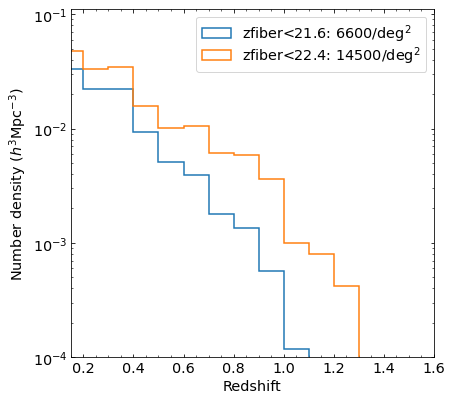

In [74]:
fig, ax = plt.subplots(figsize=(6.5, 6.4))

t = Table.read('data/desi2_low_z_dndz_zfiber_less_than_21.6.txt', format='ascii.commented_header')
bins = np.concatenate([t['zmin'], [t['zmax'][-1]]])
bin_center = (t['zmin']+t['zmax'])/2
ax.hist(bin_center, bins=bins, weights=t['comoving_density'], histtype='step', lw=1.5, label='zfiber<21.6: 6600/deg$^2$')

t = Table.read('data/desi2_low_z_dndz_zfiber_less_than_22.4.txt', format='ascii.commented_header')
bins = np.concatenate([t['zmin'], [t['zmax'][-1]]])
bin_center = (t['zmin']+t['zmax'])/2
ax.hist(bin_center, bins=bins, weights=t['comoving_density'], histtype='step', lw=1.5, label='zfiber<22.4: 14500/deg$^2$')

ax.set_xlabel('Redshift')
ax.set_ylabel('Number density $(h^3\mathrm{Mpc}^{-3})$')
ax.set_xlim(0.15, 1.6)
ax.set_yscale('log')
ax.set_ylim(0.0001, 0.11)
ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(labelspacing=0.05)
plt.show()

6142.967244701348


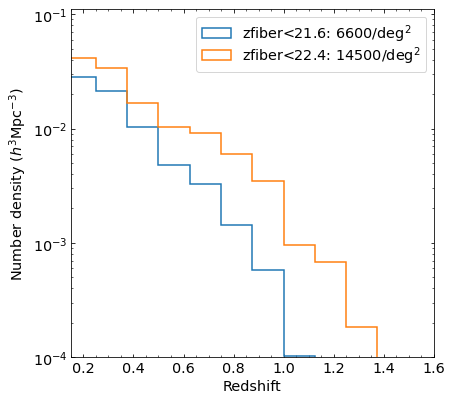

In [75]:
bins = np.linspace(0, 2.5, 21)
bin_center = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(6.5, 6.4))

mask = cat['principal'].copy()
print(np.sum(mask)/area)
densities = comoving_density(spec['ZPDF'][mask], bins, area=np.sum(mask)/6600.)
ax.hist(bin_center, bins=bins, weights=densities, histtype='step', lw=1.5, label='zfiber<21.6: 6600/deg$^2$')

mask = cat['principal'] | cat['filler_lop'] | cat['filler_hip']
densities = comoving_density(spec['ZPDF'][mask], bins, area=np.sum(mask)/14500.)
ax.hist(bin_center, bins=bins, weights=densities, histtype='step', lw=1.5, label='zfiber<22.4: 14500/deg$^2$')

ax.set_xlabel('Redshift')
ax.set_ylabel('Number density $(h^3\mathrm{Mpc}^{-3})$')
ax.set_xlim(0.15, 1.6)
ax.set_yscale('log')
ax.set_ylim(0.0001, 0.11)
ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(labelspacing=0.05)
plt.show()